In [1]:
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

Minibatch Stochastic Gradient Descent

1. randomly sample a minibatch of training examples
2. compute the gradient of the avg loss on the minibatch w respect to model params
3. multiply the gradient by a predetermined small positive value $\eta$ (learnin rate)
4. subtract resulting term from curr param vals

$$(\mathbf{w},b) \leftarrow (\mathbf{w},b) - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_{(\mathbf{w},b)} l^{(i)}(\mathbf{w},b).$$


minibatch sgd:
1. initalize vals of model params
2. iterative sample random minibatches from data, updating params in the direction of negative gradient

cool thing: quadratic losses and affine transformations have a closed-form expansion!

$$\begin{split}\begin{aligned} \mathbf{w} & \leftarrow \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_{\mathbf{w}} l^{(i)}(\mathbf{w}, b) && = \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)\\ b &\leftarrow b -  \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_b l^{(i)}(\mathbf{w}, b) &&  = b - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right). \end{aligned}\end{split}$$

hyperparameters: tunable params not updated in training loops


In [2]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)

In [3]:
c = torch.zeros(n)
t = time.time()

for i in range(n):
    c[i] = a[i] + b[i]
f'{time.time() - t:.5f} sec'

'0.16519 sec'

In [4]:
t = time.time()
d = a + b
f'{time.time() - t:.5f} sec'

'0.00000 sec'

Normal distrib with mean $\mu$ and variance $\sigma^2$  is given as 

$$p(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{1}{2 \sigma^2} (x - \mu)^2\right).$$

In [5]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 * (x - mu)**2 / sigma**2)

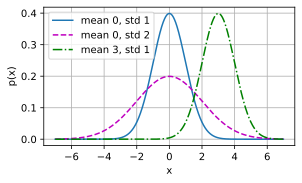

In [6]:
# Use NumPy again for visualization
x = np.arange(-7, 7, 0.01)

# Mean and standard deviation pairs
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
         ylabel='p(x)', figsize=(4.5, 2.5),
         legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

Linear Regression as a Neural Network

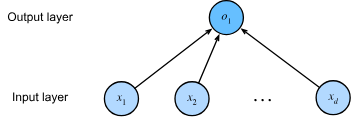

$d$ is the number of inputs in the input layer
think of linear regression as a single-layer fully connected neural network.

Exercises

1.1.

This can be thought of as a single-variate problem where $b$ is a variable we can tune to minimize $\sum_i (x_i - b)^2$.

Taking the derivative yields

\begin{align*}
\sum_i 2(x_i - b) &= 0 \\
\sum_i x_i &= nb \\
b &= \dfrac{1}{n} \sum_i x_i \\
\end{align*}

1.2. this is eqhivalent to maximum likelihood estimation if data is drawn iid from a normal distrib with mean $b$ and fixed variance
1.3. the optimal $b$ is the sample median
